# Mental Health in Tech Survey

The data used herein was sourced from:<br>
https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey/data

The `mhit` project is composed of 4 notebooks:<br>**A. Data transformations**<br> 
Because the data is unwieldy in its original form, before it was used for analysis and insights, I transformed it as follows:<br> 1. Created a unique id for each survey respondent (`rid`) and mapped all responses to this id;<br>2. Mapped all survey questions to their unique identifiers (`Q1`-`Q63`) and used the question identifiers as compact column headers.<br>3. Structured responses referencing conditions by first mapping all conditions to their own unique identifier (`C1` - `C51`) and then mapping each respondent to all of the conditions they listed as one they either currently have or one they have been diagnosed with.<br>4. Similarly, mapped all job positions to unique identifiers (`P1`-`P15`) and all respondents to each position they listed as part of their current responsibilities.<br>5. Finally, the responses are captured as text and while most represent ordinal or quantifiable information, further analysis required mapping of the text to numeric values *(e.g. "Yes" = 1 / "No" = 0 or "Yes, all" = 1, "Some of them" = 0.5, "No, none" = 0)*<br>
**B. EDA and additional data cleaning (THIS NOTEBOOK)**<br>**C. Analysis and hypothesis testing**<br>**D. NLP and Sentiment Analysis**<br>

### Library imports, notebook settings, and data files

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors 
import seaborn as sns
from collections import Counter
from cycler import cycler

In [4]:
mhit_cmap = mcolors.LinearSegmentedColormap.from_list('mhit', ['lightgray', 'steelblue'])
custom_cycler = cycler(color=[mhit_cmap(i) for i in np.linspace(0, 1, 10)][::-1])
plt.rc('axes', prop_cycle=custom_cycler)
plt.rcParams['figure.figsize'] = (5,4)
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7
plt.rcParams['figure.titlesize'] = 8
plt.rcParams['axes.titlesize'] = 8
plt.rcParams['grid.color'] = 'lightgray'
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['figure.labelsize'] = 7
pd.set_option('display.max_columns', None)

%config InlineBackend.figure_format = 'retina'

In [27]:
mhit = pd.read_csv('data/mental-heath-in-tech-2016_20161114.csv', index_col = 'rid')
mhit.sample()

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you know local or online resources to seek help for a mental health disorder?,"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?","If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?","If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?","If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",Do you believe your productivity is ever affected by a mental health issue?,"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",Do you have previous employers?,Have your previous employers provided mental health benefits?,Were you aware of the options for mental health care provided by your previous employers?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you be willing to bring up a physical health issue with a potential employer in an interview?,Why or why not?,Would you bring up a mental health issue with a potential employer in an interview?,Why or why not?.1,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a menta

In [6]:
mhit.shape

(1433, 63)

In [7]:
for i, q in enumerate(mhit.columns):
    print(f"{i+1}. {q}")

1. Are you self-employed?
2. How many employees does your company or organization have?
3. Is your employer primarily a tech company/organization?
4. Is your primary role within your company related to tech/IT?
5. Does your employer provide mental health benefits as part of healthcare coverage?
6. Do you know the options for mental health care available under your employer-provided coverage?
7. Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?
8. Does your employer offer resources to learn more about mental health concerns and options for seeking help?
9. Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?
10. If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
11. Do you think that discussing a mental health disorder with your employer would have negative c

### EDA and additional data cleaning

#### 1. Demographics

In [28]:
demo = pd.concat([mhit.iloc[:, 55:].T, mhit.iloc[:,:4].T]).T
demo.sample()

,What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?
rid,,,,,,,,,,,,
18b2a776-0240-4cfa-a2da-c6b96c2458f6,44,Male,United States of America,Ohio,United States of America,Ohio,One-person shop,Sometimes,1,NaN,NaN,NaN


In [29]:
demo['What is your age?'].dtype

dtype('O')

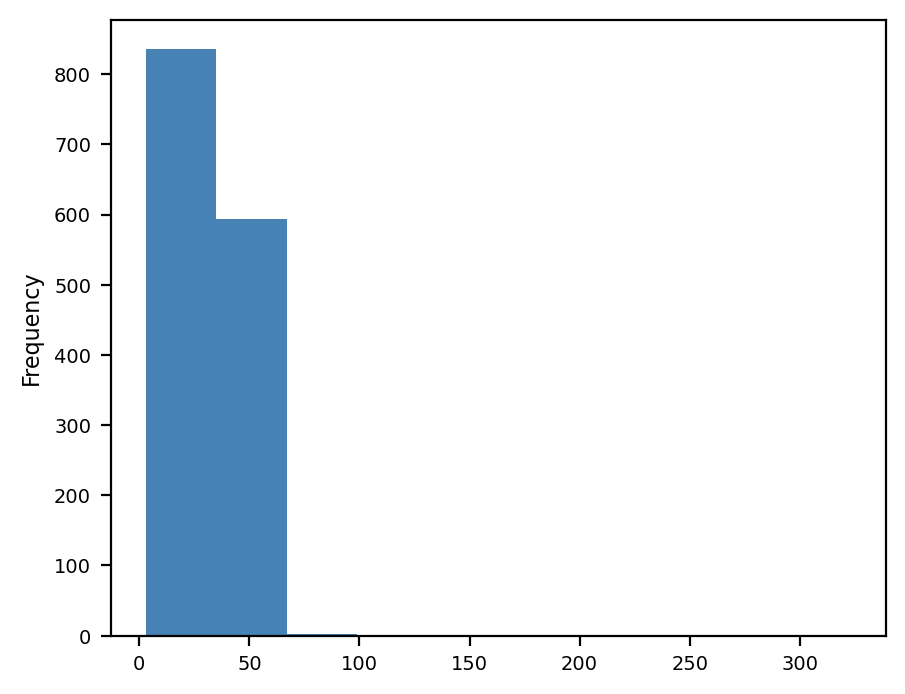

In [30]:
demo['What is your age?'] = pd.to_numeric(demo['What is your age?'])

demo['What is your age?'].plot(kind = 'hist', bins = 10);

In [31]:
demo[demo['What is your age?']>100]

,What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?
rid,,,,,,,,,,,,
cded37f9-080c-4559-a30f-acffb4794709,323,Male,United States of America,Oregon,United States of America,Oregon,Back-end Developer,Sometimes,0,100-500,1.0,NaN


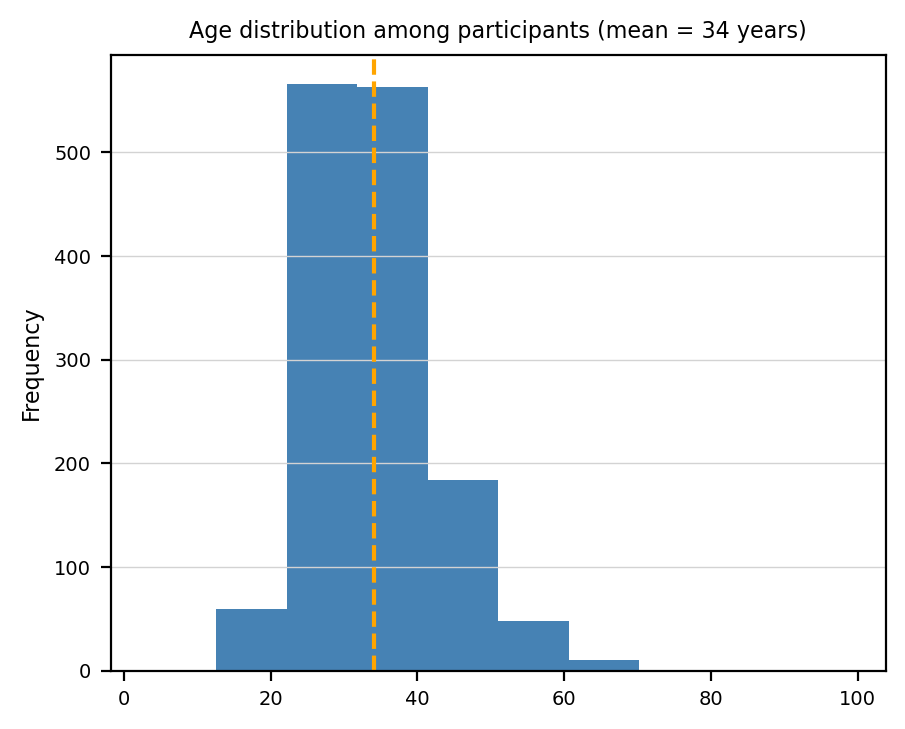

In [32]:
demo.loc['cded37f9-080c-4559-a30f-acffb4794709', 'What is your age?'] = 32

demo['What is your age?'].plot(kind = 'hist', bins = 10);
plt.axvline(demo['What is your age?'].mean(), color = 'orange', ls = '--');
plt.grid(axis = 'y', which = 'major')
plt.title(f'Age distribution among participants (mean = {round(demo['What is your age?'].mean())} years)');

In [13]:
demo['What is your gender?'].value_counts().head()

What is your gender?
Male      610
male      249
Female    153
female     95
M          86
Name: count, dtype: int64

In [14]:
demo['What is your gender?'] = demo['What is your gender?'].apply(lambda x: x.lower().strip(' ') if isinstance(x, str) else x)

demo['What is your gender?'] = demo['What is your gender?'].apply(lambda x: 'female' if isinstance(x, str) and any([_ in x for _ in ['woman', 'female']]) 
                                                                  else 'male' if isinstance(x, str) and any([_ in x for _ in ['man', 'male']]) 
                                                                  else x)

demo['What is your gender?'] = demo['What is your gender?'].apply(lambda x: 'female' if isinstance(x, str) and x in ['f', 'fm', 'fem']
                                                                  else 'male' if isinstance(x, str) and x in ['m', 'dude', 'mail', 'malr', 'm|']
                                                                  else x)

In [15]:
demo['What is your gender?'].value_counts()

What is your gender?
male                     1060
female                    344
non-binary                  4
nonbinary                   2
agender                     2
genderqueer                 2
other/transfeminine         1
transitioned, m2f           1
bigender                    1
androgynous                 1
none of your business       1
genderfluid                 1
nb masculine                1
other                       1
mtf                         1
enby                        1
queer                       1
fluid                       1
unicorn                     1
cisdude                     1
genderflux demi-girl        1
afab                        1
Name: count, dtype: int64

In [16]:
demo['What is your gender?'] = demo['What is your gender?'].apply(lambda x: 'male' if x == 'male' else 'female' if x == 'female' else 'other')

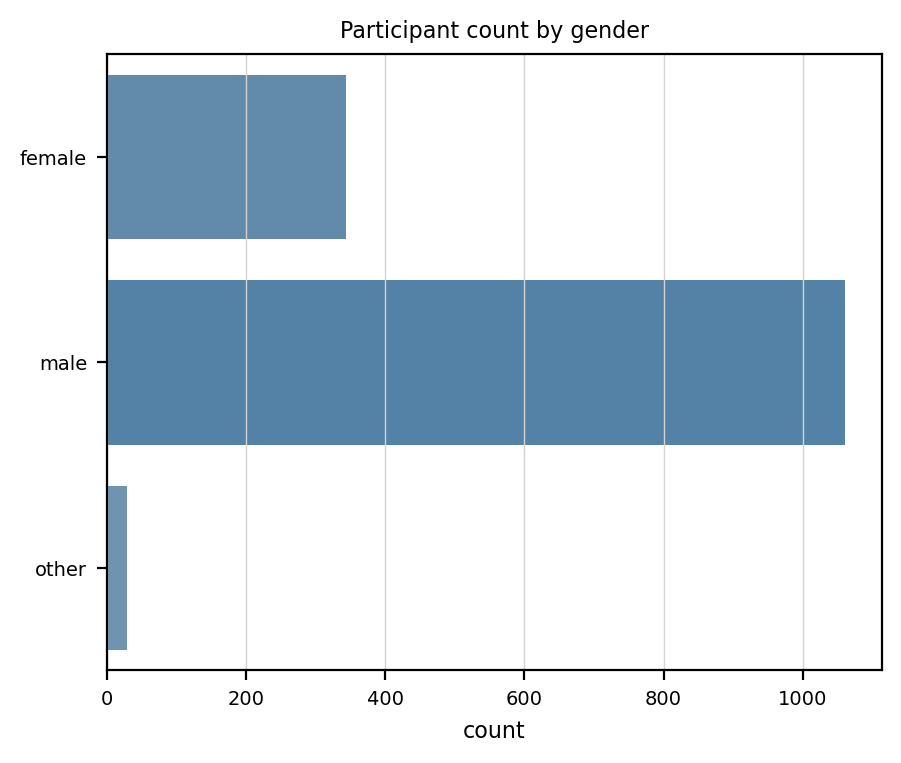

In [17]:
plt.grid(axis = 'x', which = 'major', zorder = 1)
sns.countplot(data = demo, y = 'What is your gender?', hue = 'What is your gender?', #palette = 'coolwarm_r',
             order = ['female', 'male', 'other'], legend = False, orient = 'h');
plt.ylabel(''), 
plt.title('Participant count by gender');

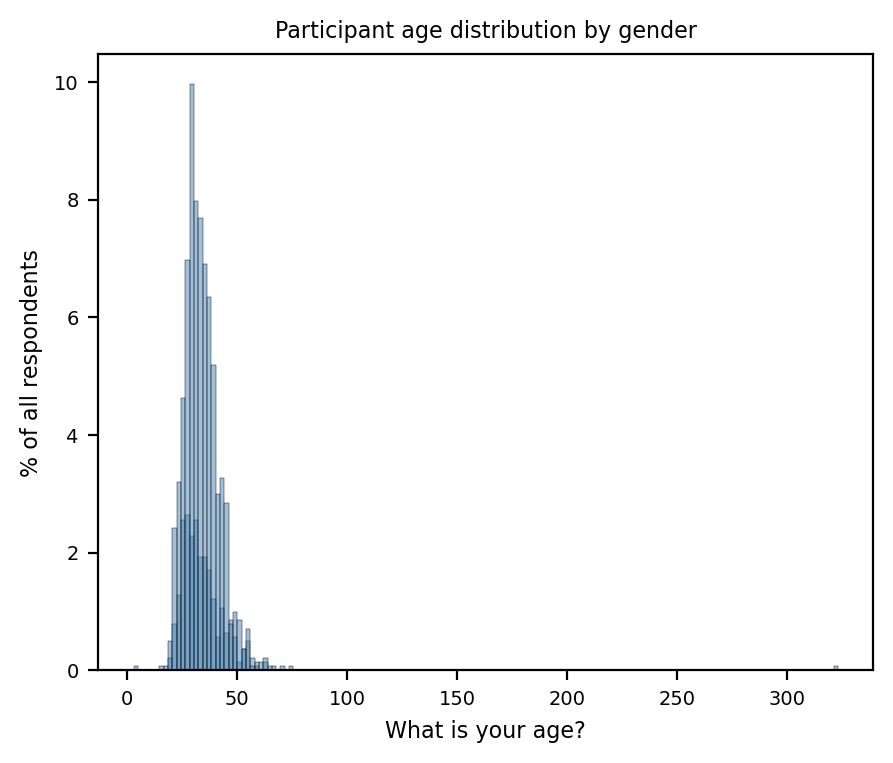

In [18]:
sns.histplot(data = demo[demo['What is your gender?'].isin(['female', 'male'])], x = 'What is your age?', stat = 'percent',
                                                           hue = 'What is your gender?',  #palette = 'coolwarm_r',
             legend = False);
plt.ylabel('% of all respondents'), 
plt.title('Participant age distribution by gender');

In [19]:
demo['What country do you live in?'].value_counts().head(20)

What country do you live in?
United States of America    840
United Kingdom              180
Canada                       78
Germany                      58
Netherlands                  48
Australia                    35
Sweden                       19
France                       16
Ireland                      15
Switzerland                  10
Brazil                       10
Russia                        9
India                         9
New Zealand                   9
Bulgaria                      7
Finland                       7
Denmark                       7
Belgium                       5
Italy                         5
Poland                        4
Name: count, dtype: int64

In [20]:
f"All but {demo[demo['What country do you live in?'] != demo['What country do you work in?']].shape[0]} participants ({round((demo[demo['What country do you live in?'] != demo['What country do you work in?']].shape[0])/demo.shape[0],3)*100}%') work and live in the same country."

"All but 27 participants (1.9%') work and live in the same country."

In [21]:
print(f"US respondents represent {demo[demo['What country do you live in?'] == 'United States of America']['What US state or territory do you live in?'].nunique()} states. Most live in:")

(demo[demo['What country do you live in?'] == 'United States of America']['What US state or territory do you live in?'].value_counts().cumsum()
 /sum(demo['What country do you live in?'] == 'United States of America')).head(10)

US respondents represent 47 states. Most live in:


What US state or territory do you live in?
California      0.154762
Illinois        0.221429
Michigan        0.278571
New York        0.332143
Washington      0.383333
Texas           0.434524
Minnesota       0.484524
Oregon          0.528571
Pennsylvania    0.567857
Colorado        0.601190
Name: count, dtype: float64

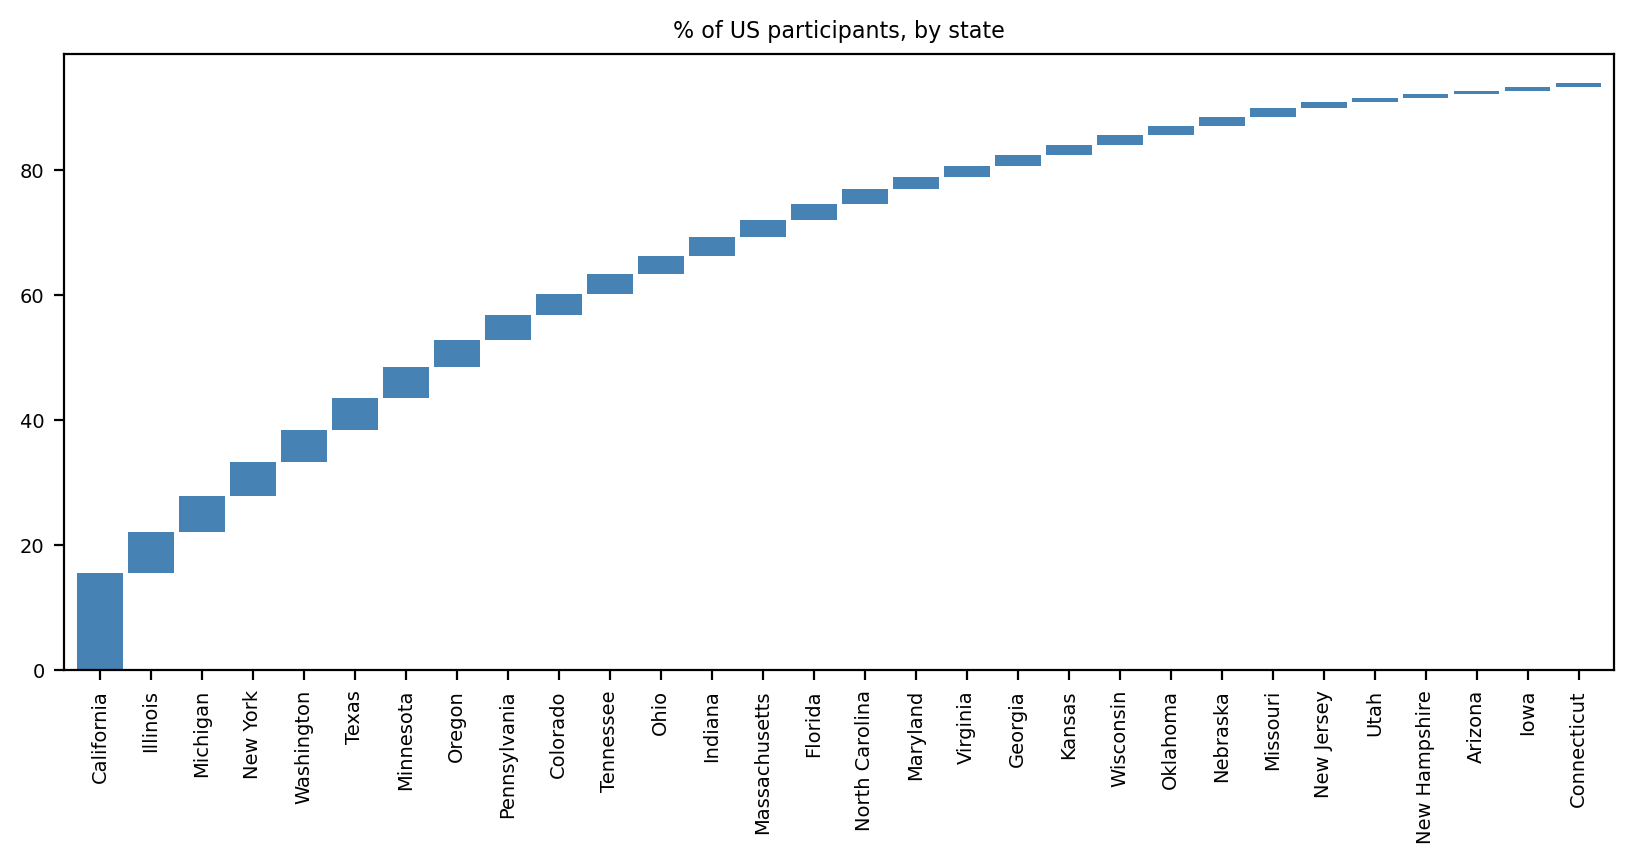

In [33]:
(100*demo[demo['What country do you live in?'] == 'United States of America']['What US state or territory do you live in?'].value_counts()/
 sum(demo['What country do you live in?'] == 'United States of America')).head(30).plot(kind = 'bar', figsize = (10,4), color = 'steelblue', width = 0.9,
                                                                                       bottom = (100*demo[demo['What country do you live in?'] == 'United States of America']['What US state or territory do you live in?'].value_counts().cumsum()/
 sum(demo['What country do you live in?'] == 'United States of America')).shift(1).fillna(0).head(30));
plt.title('% of US participants, by state');
plt.xlabel('');

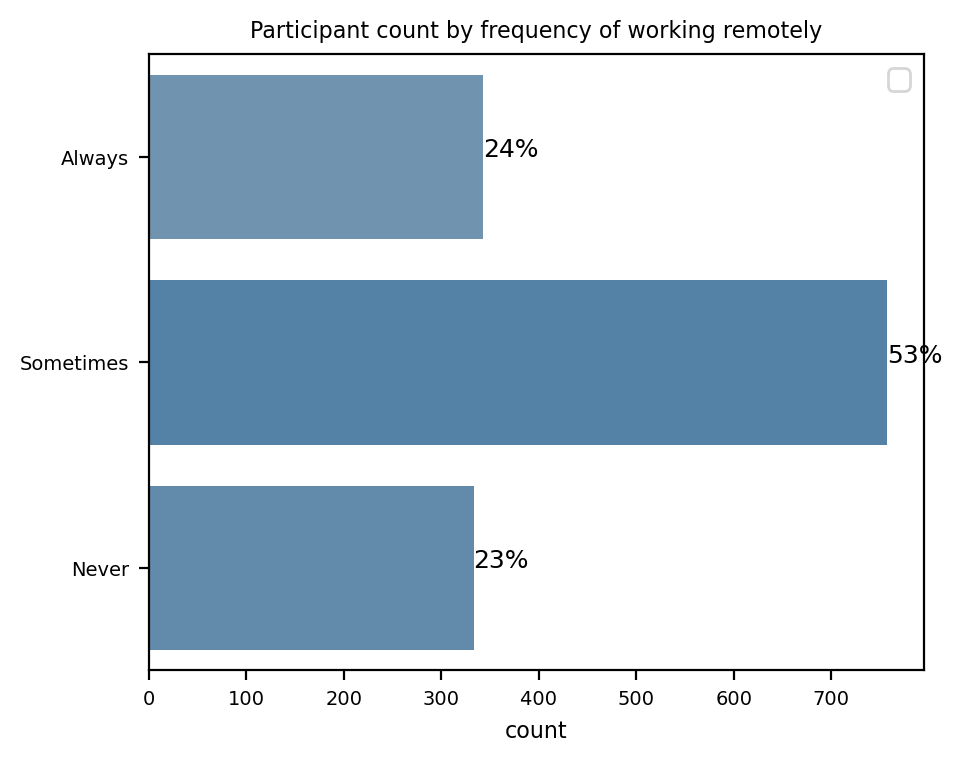

In [34]:
sns.countplot(data = demo, y = 'Do you work remotely?', hue = 'Do you work remotely?',# palette = 'viridis_r', 
             order = ['Always', 'Sometimes', 'Never'], legend = True, orient = 'h', );
for v in ['Always', 'Sometimes', 'Never']:
    plt.text(x = demo['Do you work remotely?'].value_counts(dropna = False).loc[v], y = ['Always', 'Sometimes', 'Never'].index(v), 
                  s = "{:.0%}".format((demo['Do you work remotely?'].value_counts(dropna = False)/demo.shape[0]).loc[v]), fontsize = 9)
plt.title('Participant count by frequency of working remotely')
plt.legend('')
plt.ylabel('');

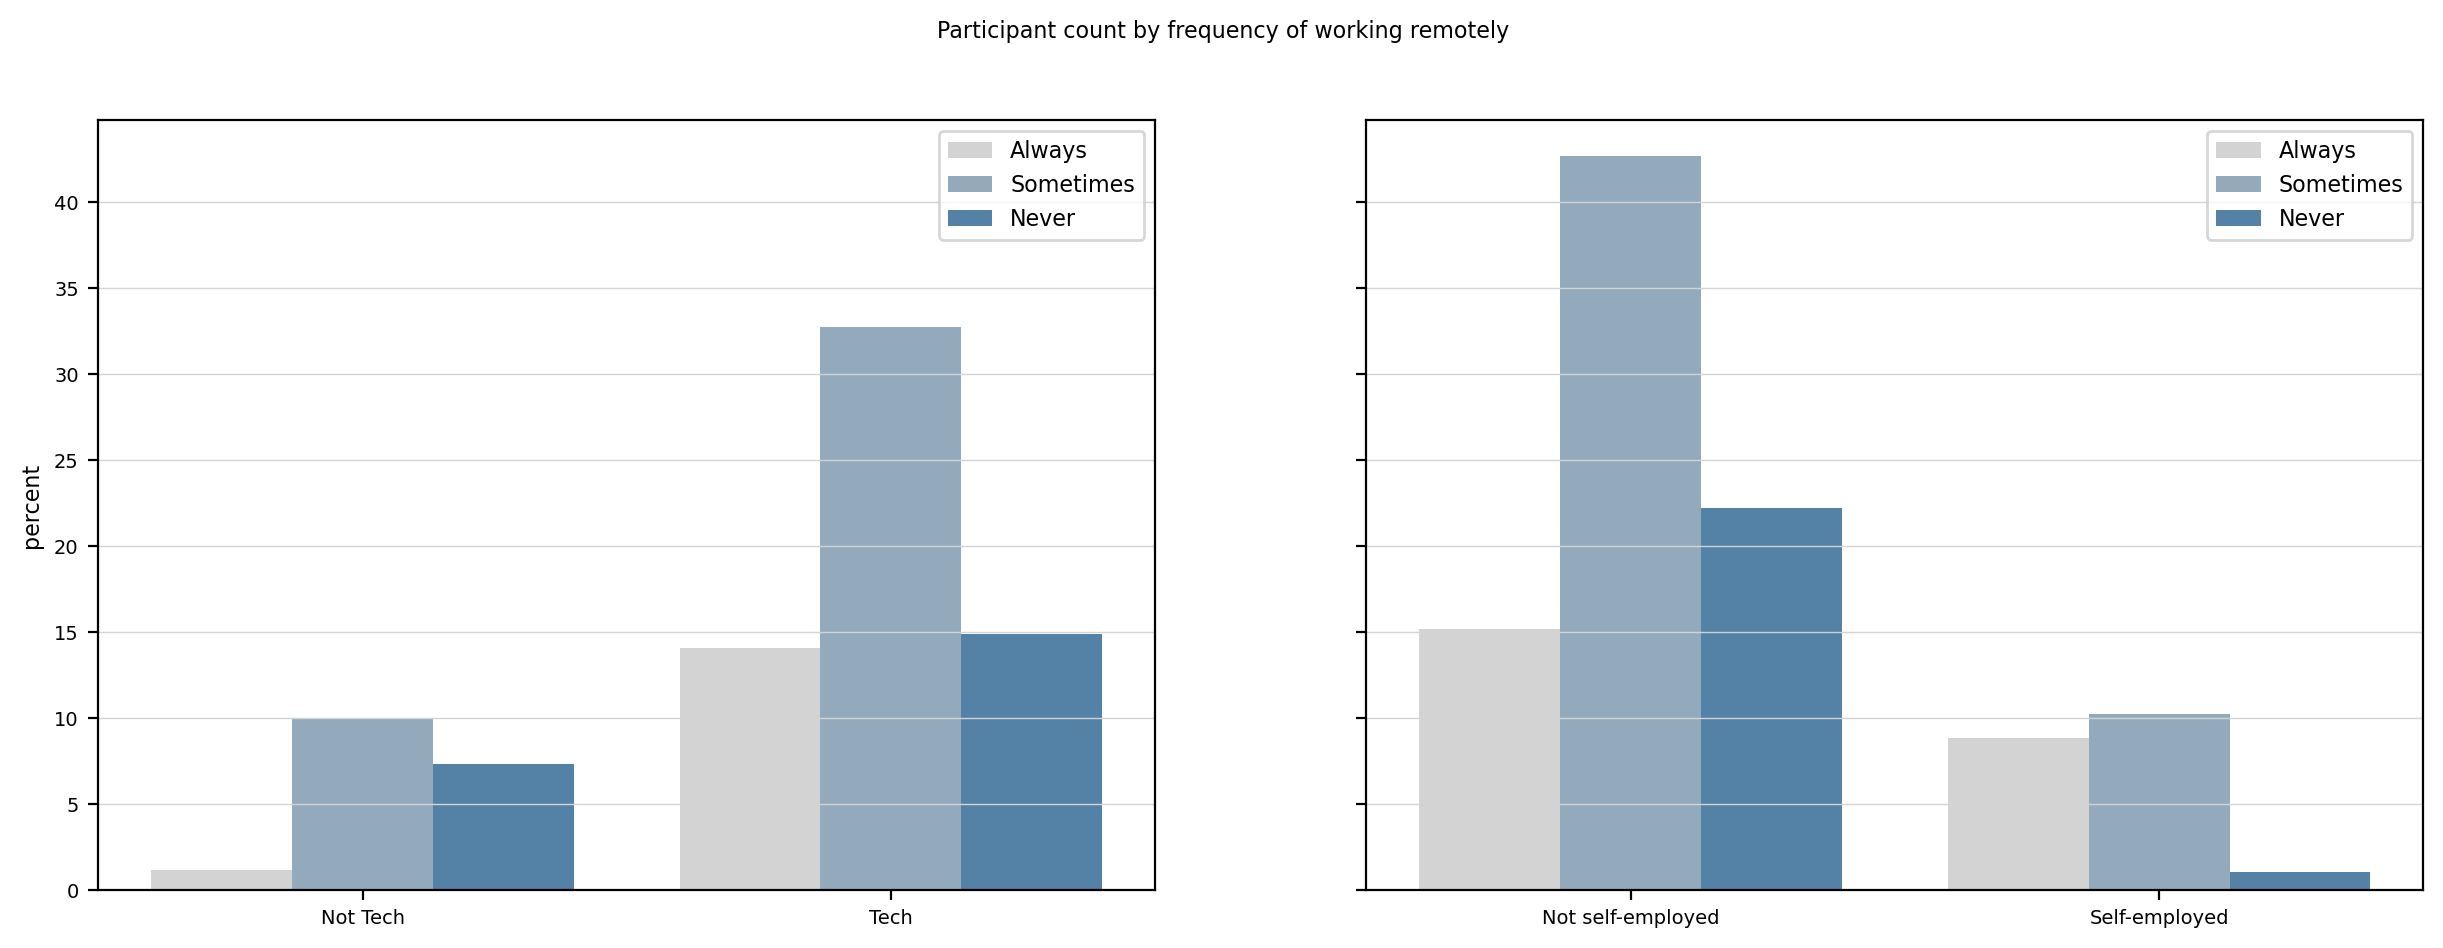

In [35]:
fig, axs = plt.subplots(1,2, figsize = (15,5), sharey = True)
plt.suptitle('Participant count by frequency of working remotely');
sns.countplot(data = demo, hue = 'Do you work remotely?', x = 'Is your employer primarily a tech company/organization?',  
                 hue_order = ['Always', 'Sometimes', 'Never'], legend = True,  stat='percent', ax = axs[0],
              palette= [mhit_cmap(i) for i in np.linspace(0,1,3)]);
axs[0].set_xticks([0,1], ['Not Tech', 'Tech'])
axs[0].set_xlabel('')
axs[0].grid(which = 'major', axis = 'y')
axs[0].legend(fontsize = 8);

sns.countplot(data = demo, hue = 'Do you work remotely?', x = 'Are you self-employed?',  
                 hue_order = ['Always', 'Sometimes', 'Never'], legend = True,  stat='percent', ax = axs[1],
              palette= [mhit_cmap(i) for i in np.linspace(0,1,3)]);
axs[1].set_xticks([0,1], ['Not self-employed', 'Self-employed'])
axs[1].set_xlabel('')
axs[1].grid(which = 'major', axis = 'y')
axs[1].legend(fontsize = 8);

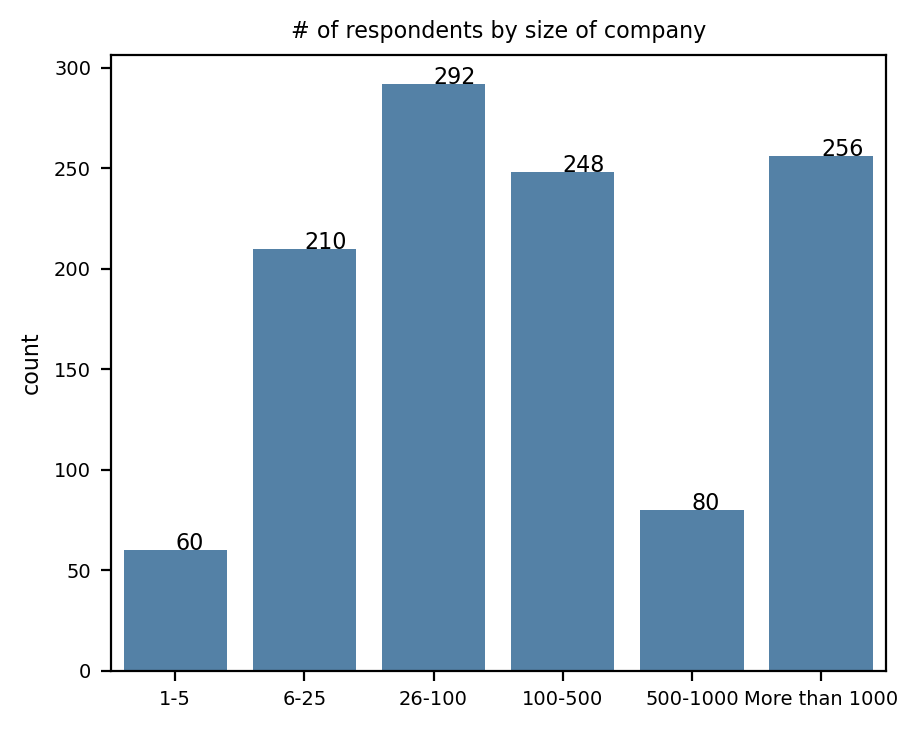

In [36]:
sns.countplot(demo[demo['Are you self-employed?']==0], x = 'How many employees does your company or organization have?', 
             order = ['1-5', '6-25', '26-100','100-500', '500-1000', 'More than 1000']);
plt.title('# of respondents by size of company');
for v in ['1-5', '6-25', '26-100','100-500', '500-1000', 'More than 1000']:
    plt.text(s = demo[demo['Are you self-employed?']==0]['How many employees does your company or organization have?'].value_counts().loc[v], 
            x = ['1-5', '6-25', '26-100','100-500', '500-1000', 'More than 1000'].index(v), fontsize = 8,
             y = demo[demo['Are you self-employed?']==0]['How many employees does your company or organization have?'].value_counts().loc[v])
plt.xlabel('');

In [37]:
demo.to_csv('demographics_w_ids.csv', index_label = 'rid')

#### 2. xxx?